## Scratch Pad to understand LLMs under the hood

In [1]:
import torch
import functools
import einops
import gc

from datasets import load_dataset
from tqdm import tqdm
from torch import Tensor
from typing import List
from transformer_lens import HookedTransformer, utils
from transformer_lens.hook_points import HookPoint
from transformers import AutoModelForCausalLM, AutoTokenizer
from jaxtyping import Float, Int
from collections import defaultdict

c:\Users\Admin\miniconda3\envs\training_pt\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Admin\AppData\Local\Temp\ipykernel_27040\2113004813.py:10: DeprecationWarning: The 'utils' module has been deprecated. Please use 'transformer_lens.utilities' instead. Importing from utils.py will be removed in TransformerLens 4.0.
  from transformer_lens import HookedTransformer, utils


In [5]:
MODEL_ID = "Qwen/Qwen3-0.6B"

# Load model and tokenizer
model = HookedTransformer.from_pretrained_no_processing(
    MODEL_ID,
    local_files_only=False,
    dtype=torch.bfloat16,
    default_padding_side='left'
).to("cuda")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.padding_side = 'left'
tokenizer.pad_token = tokenizer.eos_token

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 11517.93it/s]


Loaded pretrained model Qwen/Qwen3-0.6B into HookedTransformer
Moving model to device:  cuda


In [6]:
prompt = "How to make a veil?"

# We will use a chat template apart from normal tokenization to ensure that the model is in a chat mode and not a normal text generation mode.

tokens = tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt}],
        return_tensors="pt",
        return_dict=True,
        add_generation_prompt=True,
        enable_thinking=False 
    ).input_ids[0].to("cuda")

# If enable thinking is True, the model's raw prompt will be "<|im_start|>assistant\n"
# If enable thinking is False, the model's raw prompt will be "<|im_start|>assistant\n<think>\n\n</think>\n\n"
# Basically, the whole option is just a trick to make the model think they have finished thinking.

In [8]:
print("Basically, this is the raw input that gets inserted into the model:")
print(tokenizer.decode(tokens, skip_special_tokens=False)) # [tokens] because I don't want to render newlines, it's easier to understand this way

Basically, this is the raw input that gets inserted into the model:
<|im_start|>user
How to make a veil?<|im_end|>
<|im_start|>assistant
<think>

</think>




In [9]:
logits = model.run_with_cache(tokens)[0] # [1, seq_len, vocab]

In [10]:
raw_output = logits.argmax(dim=-1)
print("Raw output:", tokenizer.decode(raw_output)) # Raw output. For now, all tokens are garbage except the last one.
last_token = raw_output[:, -1]
print("The last (predicted) token is:", tokenizer.decode(last_token))

Raw output: ['Question\n嗯 can find a simple that What\n<|im_start|>\n:\n<think>\n</think>\n\nCreating']
The last (predicted) token is: Creating


In [11]:
# So that is for 1 token, how to pass it back to the model? just append the output into the input tokens again:
tokens = torch.tensor(tokens.tolist() + [last_token.item()])

In [12]:
print("Now, the raw input that gets inserted into the model [Notice the last word/token]:")
print(tokenizer.decode([tokens], skip_special_tokens=False))

Now, the raw input that gets inserted into the model [Notice the last word/token]:
['<|im_start|>user\nHow to make a veil?<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\nCreating']


In [13]:
# 2nd pass:
logits = model.run_with_cache(tokens)[0] # [1, seq_len, vocab]

raw_output = logits.argmax(dim=-1)
print("Raw output:", tokenizer.decode(raw_output)) # Raw output. For now, all tokens are garbage except the last one.
last_token = raw_output[:, -1]
print("The last (predicted) token is:", tokenizer.decode(last_token))

Raw output: ['Question\n嗯 can find a simple that What\n<|im_start|>\n:\n<think>\n</think>\n\nCreating a']
The last (predicted) token is:  a


In [14]:
# Let us loop it a few times to see the output everyone expects:
for i in range(15):
    tokens = torch.tensor(tokens.tolist() + [last_token.item()])
    logits = model.run_with_cache(tokens)[0] # [1, seq_len, vocab]
    raw_output = logits.argmax(dim=-1)
    last_token = raw_output[:, -1]
    print("The last token is:", tokenizer.decode(last_token))

The last token is:  veil
The last token is:  is
The last token is:  a
The last token is:  creative
The last token is:  and
The last token is:  personal
The last token is:  endeavor
The last token is: ,
The last token is:  and
The last token is:  it
The last token is: 's
The last token is:  entirely
The last token is:  up
The last token is:  to
The last token is:  you


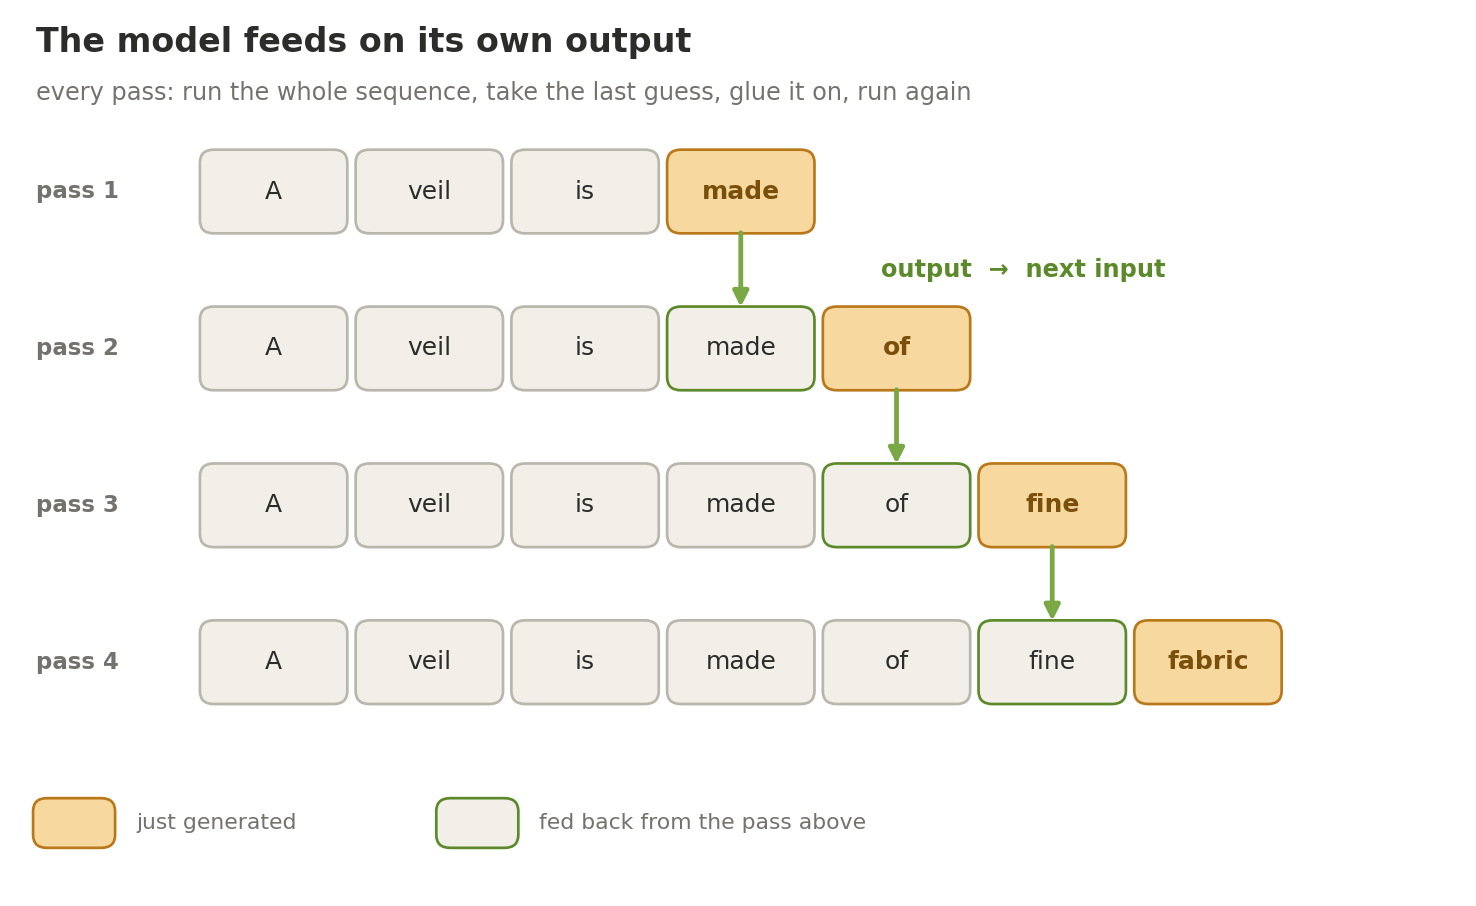

So, essentially a model is a self-feeding text generation engine